# Bulk ChIP-seq upstream: FASTQ → peaks

The earlier tutorials all started from a processed matrix. This one runs the **upstream** half of a
bulk ChIP-seq experiment with `ov.epi.upstream` (thin wrappers over bowtie2 / samtools / MACS2 /
pyBigWig): align raw reads, filter, make coverage tracks, and call peaks — then browse the result
with `ov.epi.bulk.hic`/`ov.epi.bulk.bigwig`.

**Data.** The Galaxy ChIP-seq training set: **Tal1** transcription-factor ChIP vs. input in mouse
G1E cells (GEO SRP/Zenodo record 197100), down-sampled to **chr4** so the whole pipeline runs in a
few minutes. The FASTQ and a regions BED are fetched from Zenodo on first run.

> **Tools.** Needs `bowtie2`, `samtools`, `bedtools`, `macs2` on PATH (all in the omicverse
> conda env). The bigwig step is pure `pyBigWig`/`pysam` — no deepTools required.

Pipeline: download → build a chr4 reference → align/filter/track each replicate → merge → peaks →
browse.

In [1]:
import os, pathlib, urllib.request, warnings
warnings.filterwarnings('ignore')
os.environ['LC_ALL'] = 'C'; os.environ['LC_CTYPE'] = 'C'
import pandas as pd
import matplotlib.pyplot as plt
import omicverse as ov
ov.epi.pl.plot_set()
print('omicverse', ov.__version__)

ov.epi.upstream.check_tools(['bowtie2', 'samtools', 'bedtools', 'macs2'])

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.

omicverse 2.2.1rc1
  ✓  bowtie2                    /scratch/users/steorra/env/omicdev/bin/bowtie2
  ✓  samtools                   /home/users/steorra/miniforge3/bin/samtools
  ✓  bedtools                   /home/users/steorra/miniforge3/bin/bedtools
  ✓  macs2                      /scratch/users/steorra/env/omicdev/bin/macs2


{'bowtie2': '/scratch/users/steorra/env/omicdev/bin/bowtie2',
 'samtools': '/home/users/steorra/miniforge3/bin/samtools',
 'bedtools': '/home/users/steorra/miniforge3/bin/bedtools',
 'macs2': '/scratch/users/steorra/env/omicdev/bin/macs2'}

## 1 · Download the demo reads

In [2]:
WORK = pathlib.Path.cwd() / 'data_epi' / 'chipseq'
FASTQ_DIR = WORK / 'fastq'; REF_DIR = WORK / 'ref'; OUT = WORK / 'result'
for p in [FASTQ_DIR, REF_DIR, OUT]: p.mkdir(parents=True, exist_ok=True)

CHIP_URLS = {
    'G1E_Tal1_R1.fastqsanger': 'https://zenodo.org/api/records/197100/files/G1E_Tal1_R1_downsampled_SRR492444.fastqsanger/content',
    'G1E_Tal1_R2.fastqsanger': 'https://zenodo.org/api/records/197100/files/G1E_Tal1_R2_downsampled_SRR492445.fastqsanger/content',
    'G1E_input_R1.fastqsanger': 'https://zenodo.org/api/records/197100/files/G1E_input_R1_downsampled_SRR507859.fastqsanger/content',
    'G1E_input_R2.fastqsanger': 'https://zenodo.org/api/records/197100/files/G1E_input_R2_downsampled_SRR507860.fastqsanger/content',
    'ChIPseq_regions_of_interest_v4.bed': 'https://zenodo.org/api/records/197100/files/ChIPseq_regions_of_interest_v4.bed/content',
}
for name, url in CHIP_URLS.items():
    out = FASTQ_DIR / name
    if not out.exists():
        print('downloading', name); urllib.request.urlretrieve(url, out)
chip_reps  = [('Tal1_R1', FASTQ_DIR / 'G1E_Tal1_R1.fastqsanger'),
              ('Tal1_R2', FASTQ_DIR / 'G1E_Tal1_R2.fastqsanger')]
input_reps = [('Input_R1', FASTQ_DIR / 'G1E_input_R1.fastqsanger'),
              ('Input_R2', FASTQ_DIR / 'G1E_input_R2.fastqsanger')]
regions_bed = FASTQ_DIR / 'ChIPseq_regions_of_interest_v4.bed'
print('reads ready:', [s for s, _ in chip_reps + input_reps])

reads ready: ['Tal1_R1', 'Tal1_R2', 'Input_R1', 'Input_R2']


## 2 · Build a chr4 reference

`ov.epi.upstream.fetch_genome_fasta` downloads the GRCm38 (mm10) FASTA (cached); we slice out chr4
and build a bowtie2 index for it with `ov.epi.upstream.prepare_reference`.

In [3]:
from pyfaidx import Fasta
MM10_FASTA = pathlib.Path(ov.epi.upstream.fetch_genome_fasta('GRCm38'))
CHR4_FASTA = REF_DIR / 'chr4.fa'; CHR4_BT2 = REF_DIR / 'chr4'
fa = Fasta(str(MM10_FASTA)); CHR4_SIZE = len(fa['chr4'])
if not CHR4_FASTA.exists():
    seq = str(fa['chr4'])
    with open(CHR4_FASTA, 'w') as f:
        f.write('>chr4\n')
        for i in range(0, len(seq), 60): f.write(seq[i:i+60] + '\n')
ref = ov.epi.upstream.prepare_reference(fasta=CHR4_FASTA, aligner='bowtie2', index_prefix=CHR4_BT2)
print('chr4 length:', CHR4_SIZE, '| index:', ref['ref_index'])

chr4 length: 156508116 | index: /scratch/users/steorra/analysis/omicverse_dev/guide-upstream-wt/docs/Tutorials-epigenetics/data_epi/chipseq/ref/chr4


## 3 · Align, filter and make coverage tracks

For each replicate: bowtie2 align → mark/remove duplicates → MAPQ≥30 filter → RPKM-normalised
bigwig. `ov.epi.upstream.bigwig.bam_to_bigwig` is a pure pyBigWig/pysam coverage writer.

In [4]:
def process(reps):
    runs = {}
    for name, fq in reps:
        d = OUT / name; d.mkdir(parents=True, exist_ok=True)
        raw, filt, bw = d / f'{name}.raw.bam', d / f'{name}.filtered.bam', d / f'{name}.rpkm.bw'
        for s in [raw, filt, pathlib.Path(str(filt) + '.bai'), bw]:
            if s.exists(): s.unlink()
        ov.epi.upstream.bowtie2.align_fastq_to_bam(
            fq1=str(fq), fq2=None, out_bam=raw, ref_index=ref['ref_index'],
            threads=8, extra_args=['--very-sensitive'], remove_duplicates=True)
        ov.epi.upstream.samtools.filter_bam(raw, filt, mapq=30, proper_pair=False,
            drop_secondary_supp=True, drop_unmapped=True, drop_mate_unmapped=False, threads=8)
        ov.epi.upstream.samtools.index_bam(filt, threads=8)
        ov.epi.upstream.bigwig.bam_to_bigwig(filt, bw, bin_size=25, normalize_using='RPKM', threads=8)
        raw.unlink(missing_ok=True)
        runs[name] = {'bam': str(filt), 'bigwig': str(bw)}
    return runs

chip_runs = process(chip_reps)
input_runs = process(input_reps)
print('aligned:', list(chip_runs) + list(input_runs))

[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default


344016 reads; of these:
  344016 (100.00%) were unpaired; of these:
    297031 (86.34%) aligned 0 times
    7181 (2.09%) aligned exactly 1 time
    39804 (11.57%) aligned >1 times
13.66% overall alignment rate
[bam_sort_core] merging from 0 files and 8 in-memory blocks...


[bam_sort_core] merging from 0 files and 8 in-memory blocks...


[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default


602243 reads; of these:
  602243 (100.00%) were unpaired; of these:
    525902 (87.32%) aligned 0 times
    12531 (2.08%) aligned exactly 1 time
    63810 (10.60%) aligned >1 times
12.68% overall alignment rate
[bam_sort_core] merging from 0 files and 8 in-memory blocks...


...

[bam_sort_core] merging from 0 files and 8 in-memory blocks...


[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default


3324017 reads; of these:
  3324017 (100.00%) were unpaired; of these:
    2912651 (87.62%) aligned 0 times
    55349 (1.67%) aligned exactly 1 time
    356017 (10.71%) aligned >1 times
12.38% overall alignment rate
[bam_sort_core] merging from 0 files and 8 in-memory blocks...


[bam_sort_core] merging from 0 files and 8 in-memory blocks...


aligned: ['Tal1_R1', 'Tal1_R2', 'Input_R1', 'Input_R2']


## 4 · Merge replicates and call peaks

Merge the two ChIP (and two input) BAMs, then call Tal1 peaks against the input control with
MACS2 (`ov.epi.upstream.macs2.call_peaks_macs2`).

In [5]:
merged = OUT / 'merged'; merged.mkdir(parents=True, exist_ok=True)
chip_bam = ov.epi.upstream.samtools.merge_bams(
    [chip_runs['Tal1_R1']['bam'], chip_runs['Tal1_R2']['bam']], merged / 'Tal1.filtered.bam', threads=8, index=True)
input_bam = ov.epi.upstream.samtools.merge_bams(
    [input_runs['Input_R1']['bam'], input_runs['Input_R2']['bam']], merged / 'Input.filtered.bam', threads=8, index=True)
chip_bw = ov.epi.upstream.bigwig.bam_to_bigwig(chip_bam, merged / 'Tal1.rpkm.bw', bin_size=25, normalize_using='RPKM', threads=8)
input_bw = ov.epi.upstream.bigwig.bam_to_bigwig(input_bam, merged / 'Input.rpkm.bw', bin_size=25, normalize_using='RPKM', threads=8)

peak_paths = ov.epi.upstream.macs2.call_peaks_macs2(
    bam=chip_bam, control_bam=input_bam, out_dir=OUT / 'peaks', name='G1E_Tal1',
    genome_size=str(CHR4_SIZE), format='BAM', qvalue=0.01, keep_dup='all',
    call_summits=True, nomodel=False)
peaks = pd.read_csv(peak_paths['narrowPeak'], sep='\t', header=None)
print('Tal1 peaks called:', len(peaks))
peaks.head(3)

INFO  @ Sat, 30 May 2026 10:42:40: 
# Command line: callpeak -t /scratch/users/steorra/analysis/omicverse_dev/guide-upstream-wt/docs/Tutorials-epigenetics/data_epi/chipseq/result/merged/Tal1.filtered.bam -f BAM -g 156508116 --keep-dup all -q 0.01 -n G1E_Tal1 --outdir /scratch/users/steorra/analysis/omicverse_dev/guide-upstream-wt/docs/Tutorials-epigenetics/data_epi/chipseq/result/peaks -c /scratch/users/steorra/analysis/omicverse_dev/guide-upstream-wt/docs/Tutorials-epigenetics/data_epi/chipseq/result/merged/Input.filtered.bam --call-summits
# ARGUMENTS LIST:
# name = G1E_Tal1
# format = BAM
# ChIP-seq file = ['/scratch/users/steorra/analysis/omicverse_dev/guide-upstream-wt/docs/Tutorials-epigenetics/data_epi/chipseq/result/merged/Tal1.filtered.bam']
# control file = ['/scratch/users/steorra/analysis/omicverse_dev/guide-upstream-wt/docs/Tutorials-epigenetics/data_epi/chipseq/result/merged/Input.filtered.bam']
# effective genome size = 1.57e+08
# band width = 300
# model fold = [5, 50]


Tal1 peaks called: 26


INFO  @ Sat, 30 May 2026 10:42:40: #4 Write output xls file... /scratch/users/steorra/analysis/omicverse_dev/guide-upstream-wt/docs/Tutorials-epigenetics/data_epi/chipseq/result/peaks/G1E_Tal1_peaks.xls 
INFO  @ Sat, 30 May 2026 10:42:40: #4 Write peak in narrowPeak format file... /scratch/users/steorra/analysis/omicverse_dev/guide-upstream-wt/docs/Tutorials-epigenetics/data_epi/chipseq/result/peaks/G1E_Tal1_peaks.narrowPeak 
INFO  @ Sat, 30 May 2026 10:42:40: #4 Write summits bed file... /scratch/users/steorra/analysis/omicverse_dev/guide-upstream-wt/docs/Tutorials-epigenetics/data_epi/chipseq/result/peaks/G1E_Tal1_summits.bed 
INFO  @ Sat, 30 May 2026 10:42:40: Done! 


,0,1,2,3,4,5,6,7,8,9
0,chr4,5014153,5014190,G1E_Tal1_peak_1,22,.,2.96644,6.62093,2.24047,17
1,chr4,10487101,10487138,G1E_Tal1_peak_2,40,.,3.95083,9.00442,4.09716,26
2,chr4,10871782,10871819,G1E_Tal1_peak_3,63,.,3.98759,11.40910,6.39778,17


## 5 · Browse the Tal1 locus

`ov.epi.bulk.bigwig` is a genome-browser-style track viewer. Around the *Tal1* gene the ChIP track
shows a clear enrichment over input, overlapping the called peaks.

└─ Load bigWig files
  ├─ Loading Tal1 ChIP...
  └─ Loading Input...


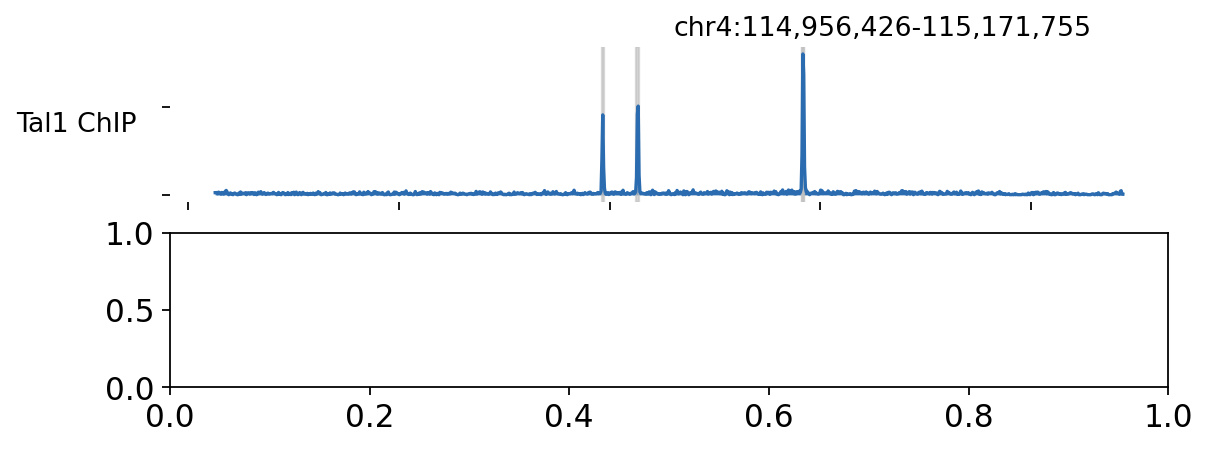

In [6]:
reg = pd.read_csv(regions_bed, sep='\t', header=None, names=['chrom', 'start', 'end', 'name'])
tal1 = reg[reg['name'].str.lower() == 'tal1'].iloc[0]
locus = (str(tal1['chrom']), int(tal1['start']), int(tal1['end']))

pk = peaks[(peaks[0] == locus[0]) & (peaks[1] < locus[2]) & (peaks[2] > locus[1])]
region_dict = {f'peak_{i+1}': (int(r[1]), int(r[2])) for i, (_, r) in enumerate(pk.head(8).iterrows())}

bw = ov.epi.bulk.bigwig({'Tal1 ChIP': str(merged / 'Tal1.rpkm.bw'), 'Input': str(merged / 'Input.rpkm.bw')})
bw.read()
bw.plot_track(chrom=locus[0], chromstart=locus[1], chromend=locus[2],
              plot_names=['Tal1 ChIP', 'Input'], figwidth=8, figheight=2.8,
              color_dict={'Tal1 ChIP': '#2B6CB0', 'Input': '#B0B0B0'},
              bp_per_bin=200, region_dict=region_dict)
plt.show()

## Summary

| stage | function |
|---|---|
| reference index | `ov.epi.upstream.fetch_genome_fasta` + `prepare_reference` |
| align → filter → track | `ov.epi.upstream.bowtie2.align_fastq_to_bam` / `samtools.filter_bam` / `bigwig.bam_to_bigwig` |
| merge replicates | `ov.epi.upstream.samtools.merge_bams` |
| peak calling | `ov.epi.upstream.macs2.call_peaks_macs2` |
| browse tracks | `ov.epi.bulk.bigwig` |

This is the generic ChIP-seq / CUT&RUN upstream recipe — swap in your own FASTQ + genome and the
same `ov.epi.upstream` calls take you from reads to a peak set and browsable tracks.